Explained variance ratio (PC1 & PC2): [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749]
Total variance captured: 0.9201754434577265


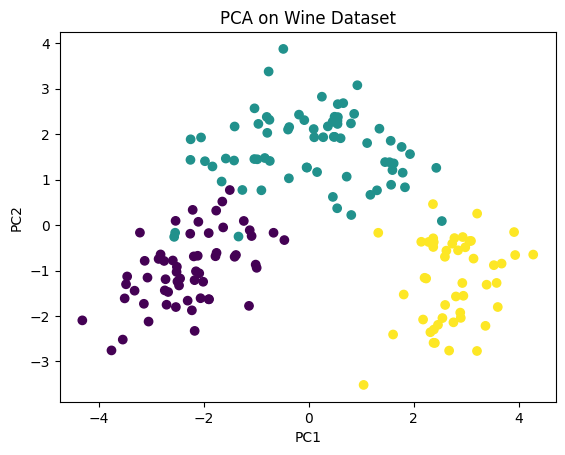

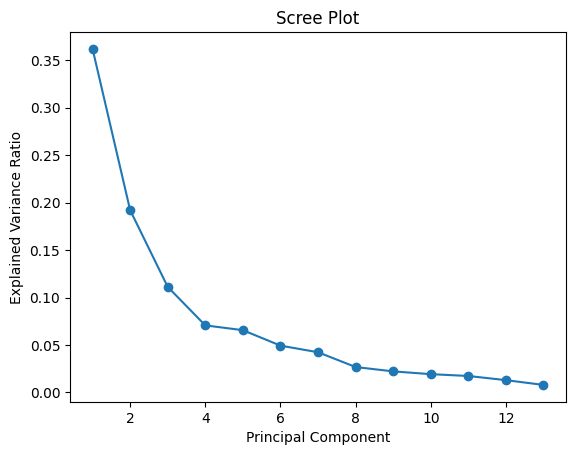

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler


class PCA:
    def __init__(self, n_components, method="eig"):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.method = method
        self.explained_variance_ratio_ = None
        self.all_explained_variance_ratio_ = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        if self.method == "eig":
            cov = np.cov(X_centered.T)
            eigenvalues, eigenvectors = np.linalg.eig(cov)

            eigenvectors = eigenvectors.T
            idxs = np.argsort(eigenvalues)[::-1]

            eigenvalues = eigenvalues[idxs]
            self.components = eigenvectors[idxs][:self.n_components]

            total_var = eigenvalues.sum()
            self.all_explained_variance_ratio_ = eigenvalues / total_var
            self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_var

        elif self.method == "svd":
            U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
            self.components = Vt[:self.n_components]

            n_samples = X_centered.shape[0]
            explained_variance = (S ** 2) / (n_samples - 1)
            total_variance = explained_variance.sum()

            self.all_explained_variance_ratio_ = explained_variance / total_variance
            self.explained_variance_ratio_ = explained_variance[:self.n_components] / total_variance

        else:
            raise ValueError("method must be 'eig' or 'svd'")

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components.T)

if __name__ == "__main__":

    data = load_wine()
    X = data.data
    y = data.target

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=8, method="svd")
    pca.fit(X_scaled)
    X_projected = pca.transform(X_scaled)

    print("Explained variance ratio (PC1 & PC2):", pca.explained_variance_ratio_)
    print("Total variance captured:", sum(pca.explained_variance_ratio_))

    plt.figure()
    plt.scatter(X_projected[:, 0], X_projected[:, 1], c=y, cmap="viridis")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA on Wine Dataset")
    plt.show()

    plt.figure()
    pcs = np.arange(1, len(pca.all_explained_variance_ratio_) + 1)
    plt.plot(pcs, pca.all_explained_variance_ratio_, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.show()